# **18. Quantun neuronal networs (QNN)/ Redes neuronales cuánticas**

# **Dive in Learning**

# ***Diplomado en Computación y Programación Cuántica***

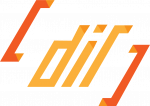

In [1]:
!pip install pennylane --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 74.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 82.1 MB/s eta 0:00:00


In [2]:
import pennylane as qml
from pennylane import numpy as np
import jax
from jax import numpy as jnp
import optax
from itertools import combinations
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import log_loss
import matplotlib.pyplot as plt
import matplotlib.colors
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

/usr/local/lib/python3.12/dist-packages/pennylane/__init__.py:209: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.6.2. You have version 0.7.2 installed. Please downgrade JAX to 0.6.2 to avoid runtime errors using python -m pip install jax~=0.6.0 jaxlib~=0.6.0
  warnings.warn(


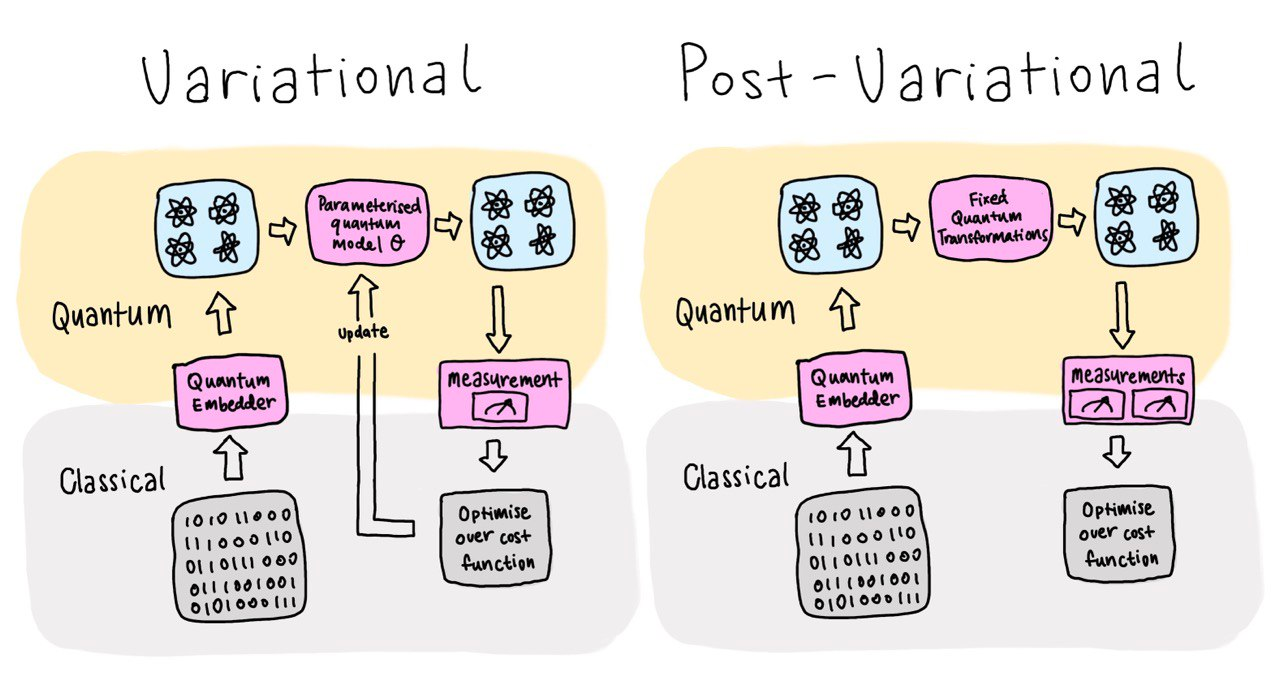

Comenzaremos entrenando nuestros modelos con el conjunto de datos de dígitos, que importamos con **sklearn**. El conjunto de datos contiene **imágenes en escala de grises de $8\times 8$ píxeles**. Particionaremos el $10$% del conjunto de datos para realizar pruebas.

In [3]:
# Cargue el conjunto de datos de dígitos con características (X_dígitos) y etiquetas (y_dígitos)
X_digits, y_digits = load_digits(return_X_y=True)

# Crea una máscara booleana para filtrar solo las muestras donde la etiqueta es 2 o 6
filter_mask = np.isin(y_digits, [2, 6])

# Aplique la máscara de filtro a las características y etiquetas para mantener solo los dígitos seleccionados
X_digits = X_digits[filter_mask]
y_digits = y_digits[filter_mask]

# Divida el conjunto de datos filtrado en conjuntos de entrenamiento y prueba con el 10 % de los datos reservados para las pruebas
X_train, X_test, y_train, y_test = train_test_split(
    X_digits, y_digits, test_size=0.1, random_state=42
)

# Normalizar los valores de los píxeles en los datos de entrenamiento y prueba
# Convierte cada imagen de una matriz 1D a una matriz 2D de 8x8, normaliza los valores de los píxeles y escálalos
X_train = np.array([thing.reshape([8, 8]) / 16 * 2 * np.pi for thing in X_train])
X_test = np.array([thing.reshape([8, 8]) / 16 * 2 * np.pi for thing in X_test])

# Ajuste las etiquetas para que estén centradas alrededor de 0 y escaladas para estar en el rango de -1 a 1
# Las etiquetas originales (2 y 6) se asignan a -1 y 1 respectivamente
y_train = (y_train - 4) / 2
y_test = (y_test - 4) / 2

A continuación se muestra una visualización de algunos puntos de datos.

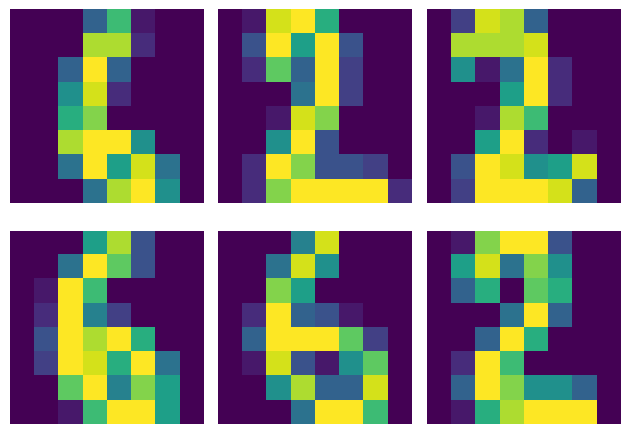

In [4]:
fig, axes = plt.subplots(nrows=2, ncols=3, layout="constrained")
for i in range(2):
    for j in range(3):
      axes[i][j].matshow(X_train[2*(2*j+i)])
      axes[i][j].axis('off')
fig.subplots_adjust(hspace=0.0)
fig.tight_layout()
plt.show()

## Configuración del modelo

Aquí, crearemos un modelo simple de Quantum Machine Learning (QML) para optimización. En particular:

* Incrustaremos nuestros datos mediante una serie de compuertas de rotación, denominadas mapa de características.

* Tendremos entonces un ansatz de compuertas de rotación con los pesos de los parámetros.

Para el mapa de características, cada columna de la imagen se codifica en un solo qubit, y cada fila se codifica consecutivamente mediante compuertas de rotación $Z$ y $X$ alternadas. El circuito de nuestro mapa de características se muestra a continuación.

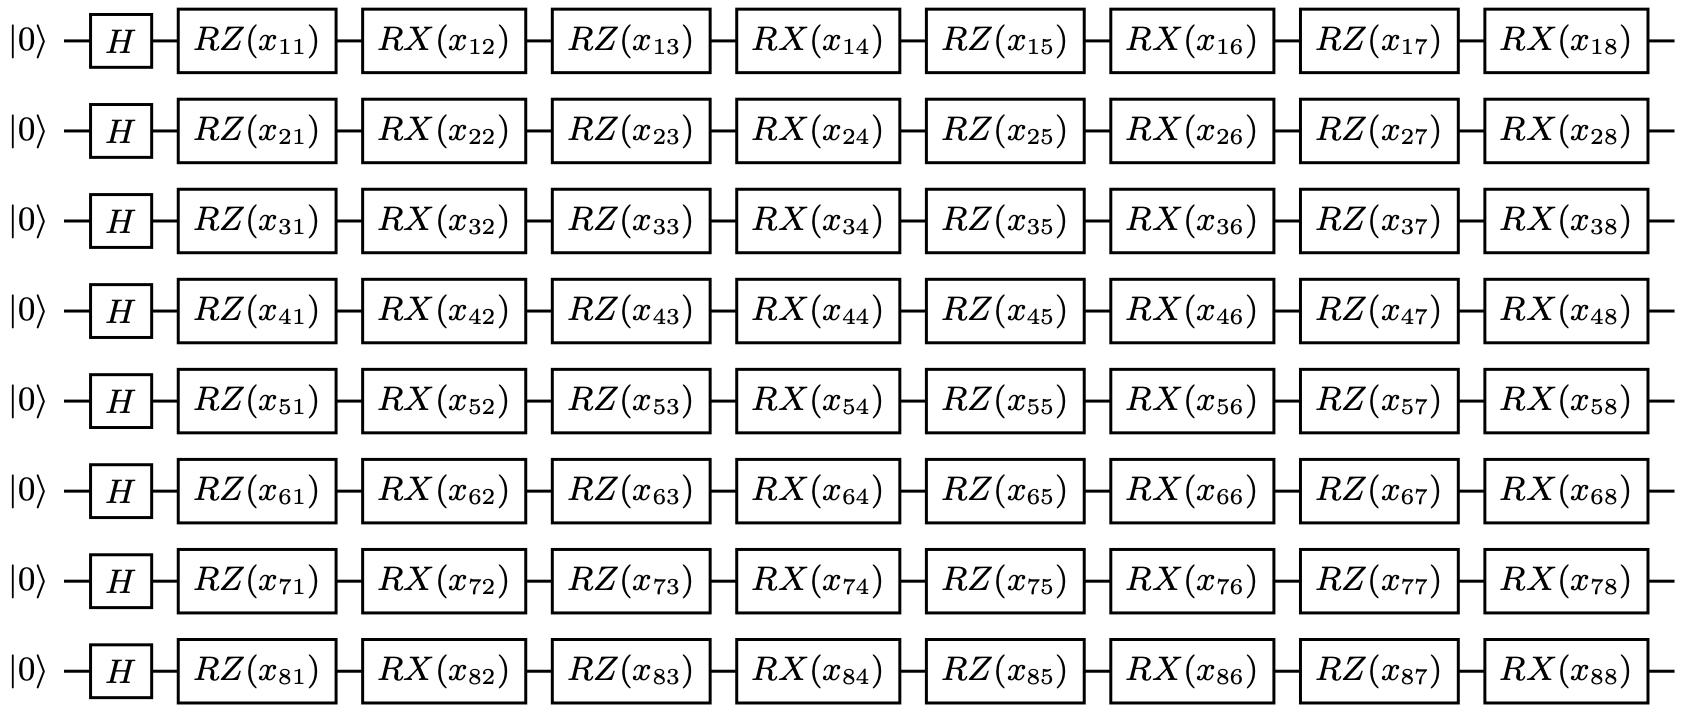

Utilizamos el siguiente circuito como ansatz. Este ansatz también sirve como columna vertebral para todas nuestras estrategias postvariacionales. Tenga en cuenta que, al establecer todos los parámetros iniciales a $0$, el ansatz se evalúa como identidad.

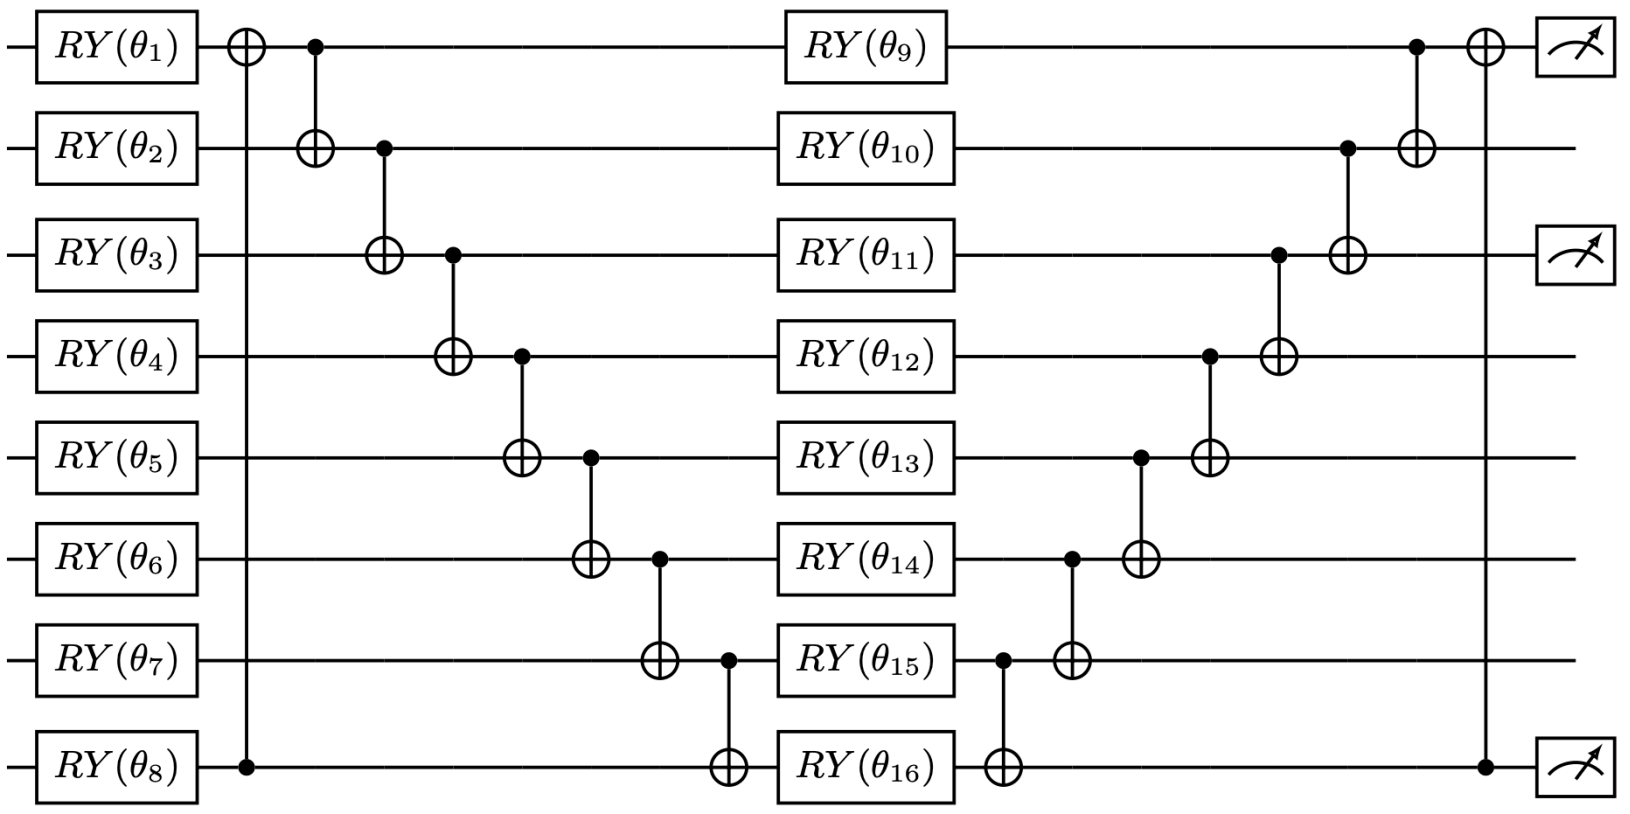

Escribimos el código para el ansatz y el mapa de características anteriores de la siguiente manera.

In [5]:
def feature_map(features):
    # Aplicar puertas de Hadamard a todos los qubits para crear un estado de superposición igual
    for i in range(len(features[0])):
        qml.Hadamard(i)

    # Aplicar incrustaciones de ángulos según los valores de las características
    for i in range(len(features)):
        # Para funciones de índice impar, utilice la rotación Z en la incrustación de ángulos
        if i % 2:
            qml.AngleEmbedding(features=features[i], wires=range(8), rotation="Z")
        # Para funciones de índice par, utilice la rotación X en la incrustación de ángulos
        else:
            qml.AngleEmbedding(features=features[i], wires=range(8), rotation="X")

# Definir el ansatz (oráculo del circuito cuántico) para operaciones cuánticas parametrizadas
def ansatz(params):
    # Aplicar rotaciones RY con el primer conjunto de parámetros
    for i in range(8):
        qml.RY(params[i], wires=i)

    # Aplicar compuertas CNOT con qubits adyacentes (conectados cíclicamente) para crear entrelazamiento
    for i in range(8):
        qml.CNOT(wires=[(i - 1) % 8, (i) % 8])

    # Aplicar rotaciones RY con el segundo conjunto de parámetros
    for i in range(8):
        qml.RY(params[i + 8], wires=i)

    # Aplicar compuertas CNOT con qubits en orden inverso (conectados cíclicamente) para crear entrelazamiento
    for i in range(8):
        qml.CNOT(wires=[(8 - 2 - i) % 8, (8 - i - 1) % 8])

## Aproximación variacional

Como comparación de referencia, primero probamos el rendimiento de un algoritmo variacional superficial en el conjunto de datos de dígitos mostrado arriba. Construiremos el nodo cuántico combinando el mapa de características y el ansatz anteriores.

In [6]:
dev = qml.device("default.qubit", wires=8)


@qml.qnode(dev)
def circuit(params, features):
    feature_map(features)
    ansatz(params)
    return qml.expval(qml.PauliZ(0))


def variational_classifier(weights, bias, x):
    return circuit(weights, x) + bias


def square_loss(labels, predictions):
    return np.mean((labels - qml.math.stack(predictions)) ** 2)


def accuracy(labels, predictions):
    acc = sum([np.sign(l) == np.sign(p) for l, p in zip(labels, predictions)])
    acc = acc / len(labels)
    return acc


def cost(params, X, Y):
    predictions = [variational_classifier(params["weights"], params["bias"], x) for x in X]
    return square_loss(Y, predictions)


def acc(params, X, Y):
    predictions = [variational_classifier(params["weights"], params["bias"], x) for x in X]
    return accuracy(Y, predictions)


np.random.seed(0)
weights = 0.01 * np.random.randn(16)
bias = jnp.array(0.0)
params = {"weights": weights, "bias": bias}
opt = optax.adam(0.05)
batch_size = 7
num_batch = X_train.shape[0] // batch_size
opt_state = opt.init(params)
X_batched = X_train.reshape([-1, batch_size, 8, 8])
y_batched = y_train.reshape([-1, batch_size])


@jax.jit
def update_step_jit(i, args):
    params, opt_state, data, targets, batch_no = args
    _data = data[batch_no % num_batch]
    _targets = targets[batch_no % num_batch]
    _, grads = jax.value_and_grad(cost)(params, _data, _targets)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return (params, opt_state, data, targets, batch_no + 1)


@jax.jit
def optimization_jit(params, data, targets):
    opt_state = opt.init(params)
    args = (params, opt_state, data, targets, 0)
    (params, opt_state, _, _, _) = jax.lax.fori_loop(0, 200, update_step_jit, args)
    return params


params = optimization_jit(params, X_batched, y_batched)
var_train_acc = acc(params, X_train, y_train)
var_test_acc = acc(params, X_test, y_test)

print("Training accuracy: ", var_train_acc)
print("Testing accuracy: ", var_test_acc)

Training accuracy:  0.7484472049689441
Testing accuracy:  0.6944444444444444


En este ejemplo, el algoritmo variacional tiene dificultades para encontrar un mínimo global (y este problema persiste incluso ajustando los hiperparámetros). Por otro lado, dada la aplicabilidad general y la consiguiente dificultad de encontrar ansätze adecuados, introducimos tres métodos heurísticos para construir el conjunto de circuitos cuánticos que conforman las redes neuronales cuánticas postvariacionales: la heurística de construcción observable, la heurística de expansión de ansatz y una combinación de ambas.

## Heurística de construcción observable

La heurística de construcción de observables elimina el uso de ansätze en el cuántico y construye mediciones directamente sobre el estado embebido de los datos cuánticos. Para simplificar, en esta demostración medimos el estado embebido de los datos con diferentes combinaciones de observables de Pauli. Primero, definimos una serie de observables de prueba $k$-locales $\mathcal{O}_{1},\mathcal{O}_{2},\ldots,\mathcal{O}_{m}$. Tras calcular los circuitos cuánticos, los resultados de las mediciones se combinan de forma clásica, donde los pesos óptimos de cada medición se calculan alimentando nuestras mediciones a un perceptrón multicapa clásico.

Generamos la serie de observables $k$-locales con el siguiente código.

In [7]:
def local_pauli_group(qubits: int, locality: int):
    assert locality <= qubits, f"Locality must not exceed the number of qubits."
    return list(generate_paulis(0, 0, "", qubits, locality))

# Esta es una función generadora recursiva que construye cadenas de Pauli.
def generate_paulis(identities: int, paulis: int, output: str, qubits: int, locality: int):
    # Caso base: si la longitud de la cadena de salida coincide con la cantidad de qubits, obtenerla.
    if len(output) == qubits:
        yield output
    else:
        # Caso recursivo: agrega una "I" (identidad) a la cadena de salida.
        yield from generate_paulis(identities + 1, paulis, output + "I", qubits, locality)

        # Si el número de operadores de Pauli utilizados es menor que la localidad, agregue "X", "Y" o "Z"
        # construye sistemáticamente todas las cadenas de Pauli posibles que se ajusten a la localidad especificada.
        if paulis < locality:
            yield from generate_paulis(identities, paulis + 1, output + "X", qubits, locality)
            yield from generate_paulis(identities, paulis + 1, output + "Y", qubits, locality)
            yield from generate_paulis(identities, paulis + 1, output + "Z", qubits, locality)

Para cada muestra de imagen, medimos la salida del circuito cuántico utilizando la secuencia de observables $k$-local y realizamos una regresión logística sobre estas salidas. Esto se hace para observables 1-local, 2-local y 3-local en el **bucle for** a continuación.

1-local: 
Training loss:  0.4592314517160884
Testing loss:  0.504588584458016
Training accuracy:  0.8074534161490683
Testing accuracy:  0.7222222222222222

2-local: 
Training loss:  0.4324277567953266
Testing loss:  0.571835844417271
Training accuracy:  0.860248447204969
Testing accuracy:  0.7222222222222222

3-local: 
Training loss:  0.42526257101770415
Testing loss:  0.5749421343266138
Training accuracy:  0.9316770186335404
Testing accuracy:  0.75



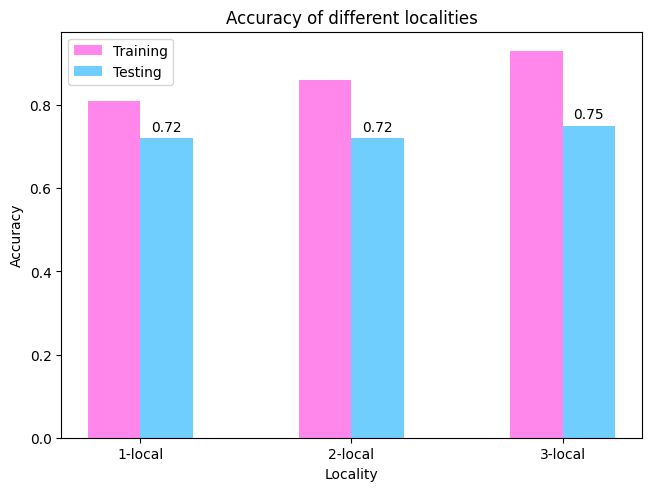

In [8]:
# Inicializar listas para almacenar precisiones de entrenamiento y pruebas para diferentes localidades.
train_accuracies_O = []
test_accuracies_O = []

for locality in range(1, 4):
    print(str(locality) + "-local: ")

    # Define un dispositivo cuántico con 8 qubits utilizando el simulador predeterminado ("defaul.qubit").
    dev = qml.device("default.qubit", wires=8)

    # Define un nodo cuántico (qnode) con el circuito cuántico que se ejecutará en el dispositivo.
    @qml.qnode(dev)
    def circuit(features):
        # Generar todas las cadenas de Pauli posibles para la localidad dada.
        measurements = local_pauli_group(8, locality)

        # Aplicar el mapa de características para codificar datos clásicos en estados cuánticos.
        feature_map(features)

        # Mide los valores esperados de los operadores de Pauli generados.
        return [qml.expval(qml.pauli.string_to_pauli_word(measurement)) for measurement in measurements]

    # Vectorizar la función del circuito cuántico para aplicarla a múltiples puntos de datos en paralelo.
    vcircuit = jax.vmap(circuit)

    # Transformar los conjuntos de datos de entrenamiento y prueba aplicando el circuito cuántico.
    new_X_train = np.asarray(vcircuit(jnp.array(X_train))).T
    new_X_test = np.asarray(vcircuit(jnp.array(X_test))).T

    # Entrenar un clasificador de perceptrón multicapa (MLP) en los datos de entrenamiento transformados.
    clf = MLPClassifier(early_stopping=True).fit(new_X_train, y_train)

    # Imprima la pérdida de registro de los datos de entrenamiento (accuracy).
    print("Training loss: ", log_loss(y_train, clf.predict_proba(new_X_train)))

    # Imprima la pérdida de registro de los datos de prueba.
    print("Testing loss: ", log_loss(y_test, clf.predict_proba(new_X_test)))

    # Calcular y almacenar la precisión del entrenamiento (accuracy).
    acc = clf.score(new_X_train, y_train)
    train_accuracies_O.append(acc)
    print("Training accuracy: ", acc)

    # Calcular y almacenar la precisión de la prueba.
    acc = clf.score(new_X_test, y_test)
    test_accuracies_O.append(acc)
    print("Testing accuracy: ", acc)
    print()

locality = ("1-local", "2-local", "3-local")
train_accuracies_O = [round(value, 2) for value in train_accuracies_O]
test_accuracies_O = [round(value, 2) for value in test_accuracies_O]
x = np.arange(3)
width = 0.25

# Cree un gráfico de barras para visualizar la precisión del entrenamiento y las pruebas.
fig, ax = plt.subplots(layout="constrained")
# Barras de precisión de entrenamiento:
rects = ax.bar(x, train_accuracies_O, width, label="Training", color="#FF87EB")
# Prueba de barras de precisión:
rects = ax.bar(x + width, test_accuracies_O, width, label="Testing", color="#70CEFF")
ax.bar_label(rects, padding=3)
ax.set_xlabel("Locality")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy of different localities")
ax.set_xticks(x + width / 2, locality)
ax.legend(loc="upper left")
plt.show()

Podemos observar que la mayor precisión se logra con los observables de 3-local, lo que proporciona al modelo clásico la mayor cantidad de información sobre las salidas del circuito. Sin embargo, este modelo requiere muchos más recursos computacionales que sus contrapartes de localidades inferiores. Cabe destacar, sin embargo, que la complejidad del método de construcción de observables locales puede reducirse considerablemente mediante el uso de sombras clásicas.

## Expansión heurística del Ansatz

El enfoque de expansión de ansatz realiza la aproximación del modelo expandiendo directamente el ansatz parametrizado en un conjunto de ansätze fijos. Partiendo de un ansatz variacional, se construyen múltiples circuitos cuánticos no parametrizados mediante la expansión de Taylor del ansatz en torno a un valor inicial adecuado de los parámetros $\theta_{0}$, que aquí se establece en $0$. Los gradientes y las derivadas de orden superior de los circuitos se pueden obtener mediante la regla de desplazamiento de parámetros. La salida de los diferentes circuitos se introduce entonces en una red neuronal clásica.

El siguiente código se utiliza para generar una serie de parámetros fijos que pueden codificarse en el ansatz mediante el método descrito anteriormente.

In [9]:
def deriv_params(thetas: int, order: int):
    # Esta función genera valores de desplazamiento de parámetros para calcular las derivadas de un circuito cuántico.
    # 'thetas' es el número de parámetros del circuito.
    # 'order' determina el orden de la derivada a calcular (1st order, 2nd order, etc.).

    def generate_shifts(thetas: int, order: int):
        # Generar todas las combinaciones posibles de parámetros a desplazar para el orden dado.
        shift_pos = list(combinations(np.arange(thetas), order))

        # Inicializar una matriz 3D para contener los valores de desplazamiento.
        # Shape: (number of combinations, 2^order, thetas)
        params = np.zeros((len(shift_pos), 2 ** order, thetas))

        # Iterar sobre cada combinación de cambios de parámetros.
        for i in range(len(shift_pos)):
            # Iterar sobre cada patrón de desplazamiento binario posible para el orden dado.
            for j in range(2 ** order):
                # Convierte el índice j en una cadena binaria de longitud 'order'.
                for k, l in enumerate(f"{j:0{order}b}"):
                    # Para cada bit de la cadena binaria:
                    if int(l) > 0:
                        # Si el bit es 1, incrementa el parámetro correspondiente.
                        params[i][j][shift_pos[i][k]] += 1
                    else:
                        # Si el bit es 0, decrementa el parámetro correspondiente.
                        params[i][j][shift_pos[i][k]] -= 1

        # Reforme la matriz de parámetros para contraer las dos primeras dimensiones.
        params = np.reshape(params, (-1, thetas))
        return params

    # Comience con una lista que contenga una matriz de desplazamiento cero para todos los parámetros.
    param_list = [np.zeros((1, thetas))]

    # Añade los valores de turno generados para cada orden 1 al orden dado.
    for i in range(1, order + 1):
        param_list.append(generate_shifts(thetas, i))

    # Concatene todas las matrices de desplazamiento a lo largo del primer eje para crear la matriz de parámetros final.
    params = np.concatenate(param_list, axis=0)

    # Escala los valores de desplazamiento por π/2.
    params *= np.pi / 2

    return params

Construimos el circuito y medimos el qubit superior con Pauli-$Z$.

In [10]:
n_wires = 8
dev = qml.device("default.qubit", wires=n_wires)

@jax.jit
@qml.qnode(dev, interface="jax")
def circuit(features, params, n_wires=8):
    feature_map(features)
    ansatz(params)
    return qml.expval(qml.PauliZ(0))

Para cada muestra de imagen, medimos las salidas de cada circuito parametrizado para cada característica y alimentamos las salidas a un perceptrón multicapa.

Order number: 1
Training loss:  0.6917395837860438
Testing loss:  0.689836609083472
Training accuracy:  0.5093167701863354
Testing accuracy:  0.5555555555555556

Order number: 2
Training loss:  0.6326008907032749
Testing loss:  0.6157803766921136
Training accuracy:  0.7018633540372671
Testing accuracy:  0.6666666666666666

Order number: 3
Training loss:  0.5815839411990991
Testing loss:  0.6016181505628401
Training accuracy:  0.7142857142857143
Testing accuracy:  0.6944444444444444



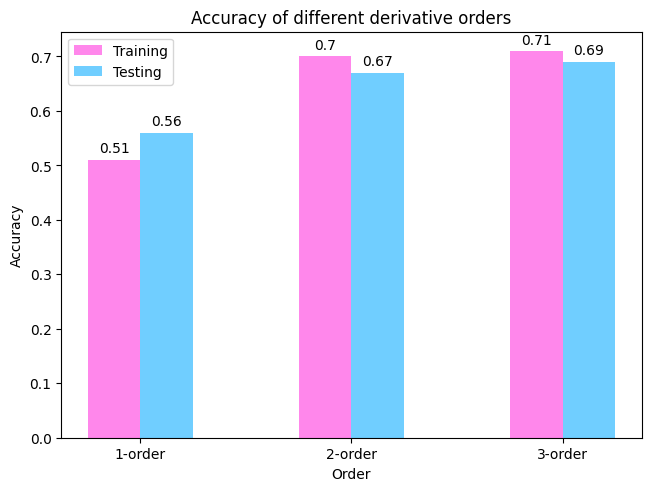

In [11]:
# Inicializar listas para almacenar precisiones de entrenamiento y pruebas para diferentes órdenes derivadas.
train_accuracies_AE = []
test_accuracies_AE = []

# Recorrer diferentes órdenes de derivadas (1st order, 2nd order, 3rd order).
for order in range(1, 4):
    print("Order number: " + str(order))

    # Genere los cambios de parámetros necesarios para el orden de derivada dado.
    to_measure = deriv_params(16, order)

    # Transforme el conjunto de datos de entrenamiento aplicando el circuito cuántico con los cambios de parámetros generados.
    new_X_train = []
    for thing in X_train:
        result = circuit(thing, to_measure.T)
        new_X_train.append(result)

    # Transforme el conjunto de datos de prueba de manera similar.
    new_X_test = []
    for thing in X_test:
        result = circuit(thing, to_measure.T)
        new_X_test.append(result)

    # Entrene un clasificador de perceptrón multicapa (MLP) en los datos de entrenamiento transformados.
    clf = MLPClassifier(early_stopping=True).fit(new_X_train, y_train)

    print("Training loss: ", log_loss(y_train, clf.predict_proba(new_X_train)))

    print("Testing loss: ", log_loss(y_test, clf.predict_proba(new_X_test)))

    acc = clf.score(new_X_train, y_train)
    train_accuracies_AE.append(acc)
    print("Training accuracy: ", acc)

    acc = clf.score(new_X_test, y_test)
    test_accuracies_AE.append(acc)
    print("Testing accuracy: ", acc)
    print()

locality = ("1-order", "2-order", "3-order")
train_accuracies_AE = [round(value, 2) for value in train_accuracies_AE]
test_accuracies_AE = [round(value, 2) for value in test_accuracies_AE]
x = np.arange(3)
width = 0.25
fig, ax = plt.subplots(layout="constrained")
rects = ax.bar(x, train_accuracies_AE, width, label="Training", color="#FF87EB")
ax.bar_label(rects, padding=3)
rects = ax.bar(x + width, test_accuracies_AE, width, label="Testing", color="#70CEFF")
ax.bar_label(rects, padding=3)
ax.set_xlabel("Order")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy of different derivative orders")
ax.set_xticks(x + width / 2, locality)
ax.legend(loc="upper left")
plt.show()

Tenga en cuenta que, al igual que con el método de construcción observable, los órdenes más altos ofrecen mayor precisión en las pruebas. Sin embargo, su ejecución es igualmente más costosa desde el punto de vista computacional.

## Estrategía híbrida

Al adoptar la estrategia de construcción de observables, se podría considerar el uso adicional de circuitos cuánticos ansatz para aumentar la complejidad del modelo. Por lo tanto, presentamos una estrategia híbrida simple que combina el uso de la expansión de ansatz y la construcción de observables. Para cada característica, primero expandimos el ansatz con cada uno de nuestros parámetros y luego usamos cada observable $k$-local para realizar mediciones.

Debido al gran número de circuitos que deben calcularse con esta estrategia, se podría optar por podar aún más los circuitos utilizados en el entrenamiento, pero esto no se realiza en esta demostración.

Tenga en cuenta que en nuestro ejemplo, solo probamos tres muestras híbridas para reducir el tiempo de ejecución de este script, pero se pueden probar otras combinaciones de ambas estrategias para obtener mejores resultados.

In [12]:
# Inicializar matrices para almacenar precisiones de entrenamiento y prueba para diferentes
# combinaciones de localidad y orden.
train_accuracies = np.zeros([4, 4])
test_accuracies = np.zeros([4, 4])

# Recorrer diferentes órdenes de derivadas (1 a 3) y localidades (1-local a 3-local).
for order in range(1, 4):
    for locality in range(1, 4):
        # Omite combinaciones no válidas donde localidad + orden exceda 3 o sea igual a 0.
        if locality + order > 3 or locality + order == 0:
            continue
        print("Locality: " + str(locality) + " Order: " + str(order))

        # Define un dispositivo cuántico con 8 qubits utilizando el simulador predeterminado.
        dev = qml.device("default.qubit", wires=8)

        # Genere los cambios de parámetros necesarios para el orden de derivada dado y transpóngalos (con .T).
        params = deriv_params(16, order).T

        # Define un nodo cuántico (qnode) con el circuito cuántico que se ejecutará en el dispositivo.
        @qml.qnode(dev)
        def circuit(features, params):
            # Generar el grupo de Pauli para la localidad dada.
            measurements = local_pauli_group(8, locality)
            feature_map(features)
            ansatz(params)
            # Mide los valores esperados de los operadores de Pauli generados.
            return [qml.expval(qml.pauli.string_to_pauli_word(measurement)) for measurement in measurements]

        # Vectorizar la función del circuito cuántico para aplicarla a múltiples puntos de datos en paralelo.
        vcircuit = jax.vmap(circuit)

        # Transforme el conjunto de datos de entrenamiento aplicando el circuito cuántico
        # con los cambios de parámetros generados.
        new_X_train = np.asarray(
            vcircuit(jnp.array(X_train), jnp.array([params for i in range(len(X_train))]))
        )
        # Reordenar los ejes y remodelar los datos transformados para ingresarlos en el clasificador.
        new_X_train = np.moveaxis(new_X_train, 0, -1).reshape(
            -1, len(local_pauli_group(8, locality)) * len(deriv_params(16, order))
        )

        # Transforme el conjunto de datos de prueba de manera similar.
        new_X_test = np.asarray(
            vcircuit(jnp.array(X_test), jnp.array([params for i in range(len(X_test))]))
        )
        # Reordenar los ejes y remodelar los datos transformados para ingresarlos en el clasificador.
        new_X_test = np.moveaxis(new_X_test, 0, -1).reshape(
            -1, len(local_pauli_group(8, locality)) * len(deriv_params(16, order))
        )

        # Entrene un clasificador de perceptrón multicapa (MLP) en los datos de entrenamiento transformados.
        clf = MLPClassifier(early_stopping=True).fit(new_X_train, y_train)

        # Calcular y almacenar las precisiones de entrenamiento y pruebas.
        train_accuracies[order][locality] = clf.score(new_X_train, y_train)
        test_accuracies[order][locality] = clf.score(new_X_test, y_test)

        print("Training loss: ", log_loss(y_train, clf.predict_proba(new_X_train)))
        print("Testing loss: ", log_loss(y_test, clf.predict_proba(new_X_test)))
        acc = clf.score(new_X_train, y_train)
        train_accuracies[locality][order] = acc
        print("Training accuracy: ", acc)
        acc = clf.score(new_X_test, y_test)
        test_accuracies[locality][order] = acc
        print("Testing accuracy: ", acc)
        print()

Locality: 1 Order: 1
Training loss:  0.2943312057720091
Testing loss:  0.48158007150130455
Training accuracy:  0.8944099378881988
Testing accuracy:  0.7777777777777778

Locality: 2 Order: 1
Training loss:  0.3278434857289445
Testing loss:  0.5719674854945823
Training accuracy:  0.8664596273291926
Testing accuracy:  0.75

Locality: 1 Order: 2
Training loss:  0.20259992965007712
Testing loss:  0.5550613388063061
Training accuracy:  0.9409937888198758
Testing accuracy:  0.75



Al obtener nuestros resultados híbridos, ahora podemos combinar estos resultados con los de los métodos de construcción observables y de expansión de ansatz, y trazar todas las estrategias post-variacionales juntas en un mapa de calor.

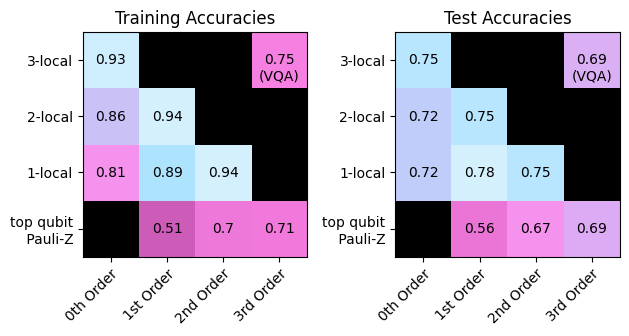

In [13]:
for locality in range(1, 4):
    train_accuracies[locality][0] = train_accuracies_O[locality - 1]
    test_accuracies[locality][0] = test_accuracies_O[locality - 1]
for order in range(1, 4):
    train_accuracies[0][order] = train_accuracies_AE[order - 1]
    test_accuracies[0][order] = test_accuracies_AE[order - 1]

train_accuracies[3][3] = var_train_acc
test_accuracies[3][3] = var_test_acc

cvals = [0, 0.5, 0.85, 0.95, 1]
colors = ["black", "#C756B2", "#FF87EB", "#ACE3FF", "#D5F0FD"]
norm = plt.Normalize(min(cvals), max(cvals))
tuples = list(zip(map(norm, cvals), colors))
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", tuples)


locality = ["top qubit\n Pauli-Z", "1-local", "2-local", "3-local"]
order = ["0th Order", "1st Order", "2nd Order", "3rd Order"]

fig, axes = plt.subplots(nrows=1, ncols=2, layout="constrained")
im = axes[0].imshow(train_accuracies, cmap=cmap, origin="lower")

axes[0].set_yticks(np.arange(len(locality)), labels=locality)
axes[0].set_xticks(np.arange(len(order)), labels=order)
plt.setp(axes[0].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(locality)):
    for j in range(len(order)):
        text = axes[0].text(
            j, i, np.round(train_accuracies[i, j], 2), ha="center", va="center", color="black"
        )
axes[0].text(3, 3, '\n\n(VQA)', ha="center", va="center", color="black")

axes[0].set_title("Training Accuracies")

locality = ["top qubit\n Pauli-Z", "1-local", "2-local", "3-local"]
order = ["0th Order", "1st Order", "2nd Order", "3rd Order"]

im = axes[1].imshow(test_accuracies, cmap=cmap, origin="lower")

axes[1].set_yticks(np.arange(len(locality)), labels=locality)
axes[1].set_xticks(np.arange(len(order)), labels=order)
plt.setp(axes[1].get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
for i in range(len(locality)):
    for j in range(len(order)):
        text = axes[1].text(
            j, i, np.round(test_accuracies[i, j], 2), ha="center", va="center", color="black"
        )
axes[1].text(3, 3, '\n\n(VQA)', ha="center", va="center", color="black")

axes[1].set_title("Test Accuracies")
fig.tight_layout()
plt.show()